# 11. Full Chain Stress Test (Max Complexity)
This example demonstrates the maximum capability of `curaster` in a single chained pipeline. It reads a massive **XL** raster (16384 x 16384 pixels) directly from S3, applies a boolean spectral mask, clips it to a dynamic GeoJSON polygon, computes all **9** available terrain metrics (triggering multi-band GPU focal processing), and streams the result directly back to an S3 bucket.

## 1. Setup AWS Credentials and Input/Output URIs
Ensure your environment variables are configured. For `curaster` to write to S3, GDAL utilizes `/vsis3/` paths.

In [ ]:
import curaster
import os
import json

# Ensure AWS credentials are set (replace with your own if needed)
os.environ.setdefault("AWS_ACCESS_KEY_ID",     "")
os.environ.setdefault("AWS_SECRET_ACCESS_KEY", "")
os.environ.setdefault("AWS_DEFAULT_REGION",    "eu-central-1")

# Max test size (16384 x 16384) in the S3 benchmark bucket
input_s3 = "/vsis3/bucket/test_XL_16384x16384_lzw_b512_band.tif"

# Direct S3 write output path via GDAL VSI
output_s3 = "/vsis3/bucket/output/terrain_stress_XL_9band.tif"


## 2. Dynamic AOI Generation
We will extract the spatial extent of the input image without downloading the pixel data, using `get_info()`, and construct a polygon representing the inner 80% of the image.

In [2]:
# Get info to dynamically create a clip polygon (reads only the GeoTIFF header)
info = curaster.open(input_s3).get_info()
gt = info["geotransform"]
w, h = info["width"], info["height"]

# Create an AOI covering the middle 80% of the image
x0 = gt[0] + gt[1] * (w * 0.1)
x1 = gt[0] + gt[1] * (w * 0.9)
y0 = gt[3] + gt[5] * (h * 0.1)
y1 = gt[3] + gt[5] * (h * 0.9)

aoi = json.dumps({
    "type": "Polygon",
    "coordinates": [[
        [x0, y0], [x1, y0], [x1, y1], [x0, y1], [x0, y0]
    ]]
})

print(f"Original size: {w} x {h}")


Original size: 16384 x 16384


## 3. Build the Lazy Chain
The chain is not executed until `.save_s3()` is called. We will stack the following operations:
1. **`algebra()`**: Apply a conditional threshold mask (zeroing pixels below 500, preserving Band 1 otherwise).
2. **`clip()`**: Mask out all pixels outside the GeoJSON polygon we generated.
3. **`terrain()`**: Compute all 9 available terrain derivatives (`slope`, `aspect`, `hillshade`, `tri`, `tpi`, `roughness`, `prof_curv`, `plan_curv`, `total_curv`) using the Horn (3x3) method.

In [11]:
chain = curaster.open(input_s3) \
    .algebra("(B1 > 500) * B1") \
    .clip(aoi) \
    .terrain(
        metrics=["slope","aspect"],
        unit="degrees",
        method="horn"
    )

print("Lazy execution chain built successfully.")


Lazy execution chain built successfully.


## 4. Execute and Stream directly to S3
The operation will execute in chunks, utilizing multi-threaded parallel execution across the GPU and CPU to compute and upload the resulting **9-band** raster directly to S3 without overflowing system RAM. Total pixel throughput generated: **~2.4 Billion pixels!**

In [12]:
%%time

# Execute the pipeline and stream the result directly back to S3
chain.save_s3(output_s3, verbose=True)

print(f"\nSuccessfully uploaded 9-band multi-metric terrain output to {output_s3}")


0
Successfully uploaded 9-band multi-metric terrain output to /vsis3/misc-jspuri/curaster-bench/output/terrain_stress_XL_9band.tif
CPU times: user 1min 10s, sys: 6.96 s, total: 1min 17s
Wall time: 1min 26s
...10...20...30...40...50...60...70...80...90...100 - done.

[save_s3] Uploading /tmp/curaster_s3_17730.tif → /vsis3/misc-jspuri/curaster-bench/output/terrain_stress_XL_9band.tif


## 5. Visualizing a Chunk (Stream Inspection)
If you want to inspect what the pipeline is doing without writing the entire 16k x 16k image to disk, you can use `.iter_begin()` to stream the data, grab the very first processed chunk, and visualize it using `matplotlib`.

Chunk 0: y_offset=15360, shape=(2, 1024, 16384)
Chunk 1: y_offset=0, shape=(2, 5120, 16384)


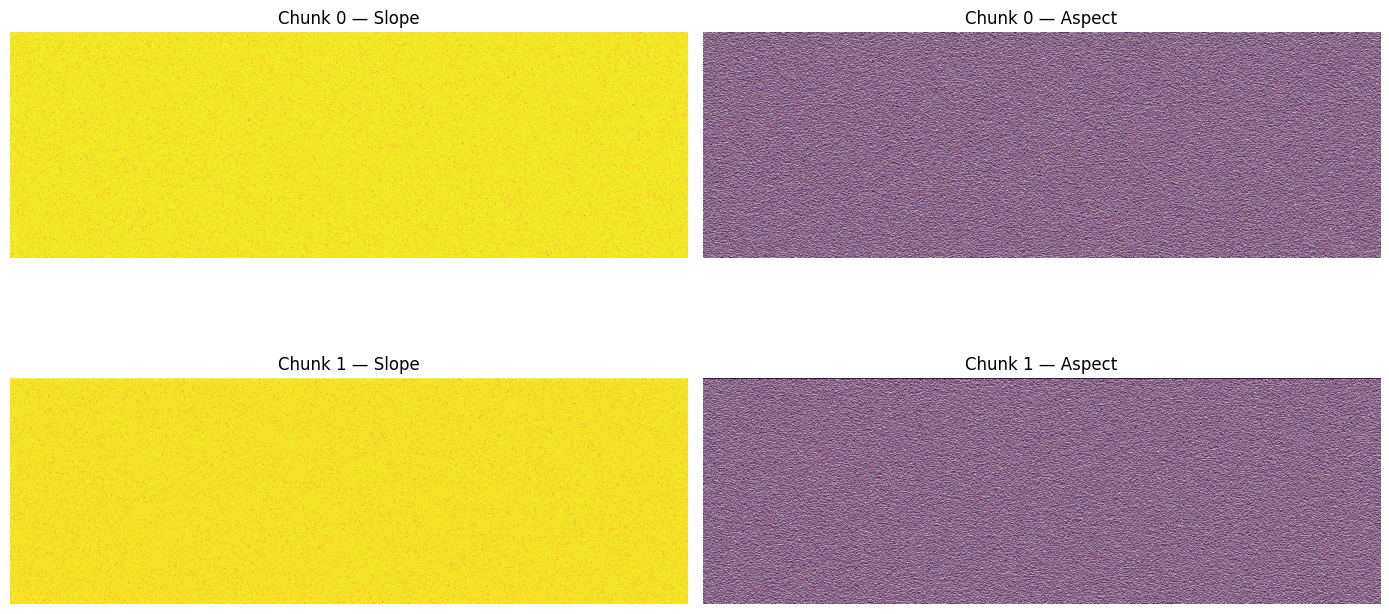

In [13]:
queue = chain.iter_begin(buf_chunks=4)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
chunk_labels = ["Chunk 0", "Chunk 1"]
band_labels  = ["Slope", "Aspect"]
cmaps        = ["plasma", "twilight"]

for row in range(2):
    chunk = queue.next()
    if chunk is None:
        print(f"No chunk {row}")
        break

    data = chunk["data"]   # (2, H, W)
    y0   = chunk["y_offset"]
    h, w = data.shape[1], data.shape[2]
    plot_w = min(1500, w)
    plot_h = min(500,  h)

    print(f"Chunk {row}: y_offset={y0}, shape={data.shape}")

    for col in range(2):
        axes[row, col].imshow(data[col, :plot_h, :plot_w], cmap=cmaps[col])
        axes[row, col].set_title(f"{chunk_labels[row]} — {band_labels[col]}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()